# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [135]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import geopandas as gpd


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [136]:
# Load data
data = pd.read_csv('data/bcn_noise_ml_dataset.csv')
print(data)

                       road_id  noise_day  noise_evening  noise_night  \
0      13845167536_847716886_0         55             55           50   
1          21638869_30343583_0         55             50           50   
2         21638869_242318729_0         55             55           50   
3          21638869_30343672_0         60             60           55   
4       3055187877_431100338_0         60             60           55   
...                        ...        ...            ...          ...   
11664  2239783361_4577282718_0         60             60           55   
11665   2239783361_885307899_0         60             60           55   
11666   885307964_4577282718_0         60             60           55   
11667    885307964_885307899_0         60             60           55   
11668    885307899_885307964_0         60             60           55   

       road_length  road_category  dist_to_main  signals  transport   pois  \
0          401.484              5       258.6

In [137]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11669 entries, 0 to 11668
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          11669 non-null  str    
 1   noise_day        11669 non-null  int64  
 2   noise_evening    11669 non-null  int64  
 3   noise_night      11669 non-null  int64  
 4   road_length      11669 non-null  float64
 5   road_category    11669 non-null  int64  
 6   dist_to_main     11669 non-null  float64
 7   signals          11669 non-null  float64
 8   transport        11669 non-null  float64
 9   pois             11669 non-null  float64
 10  width            11669 non-null  float64
 11  height           11669 non-null  float64
 12  betw_centrality  11669 non-null  float64
 13  clos_centrality  11669 non-null  float64
 14  green_100        11669 non-null  float64
dtypes: float64(10), int64(4), str(1)
memory usage: 1.3 MB


## Predicting Street-level Noise


### Select features (X)

In [138]:
# Select the (independant) features that we are going to use to train the model
X = data[['clos_centrality','dist_to_main','signals']]
X

,clos_centrality,dist_to_main,signals
0,0.000,258.681,0.249
1,0.000,429.190,1.106
2,0.000,512.334,6.655
3,0.000,516.423,6.504
4,0.000,214.042,2.170
...,...,...,...
11664,0.000,1013.939,16.187
11665,0.000,1013.939,4.466
11666,0.000,1035.026,4.445
11667,0.000,1061.399,3.723


### Standard scaling

In [139]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

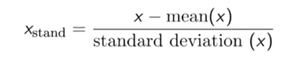

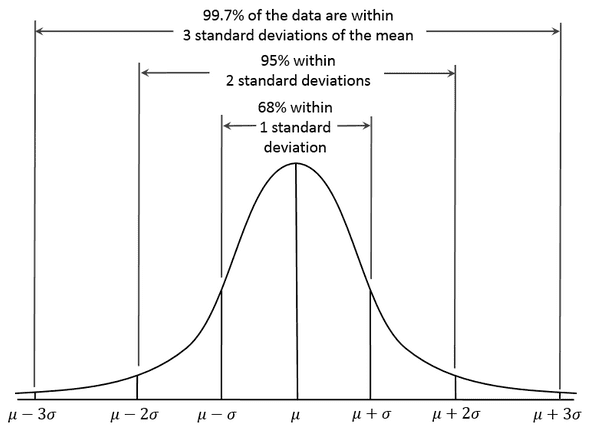

In [140]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 8.46145596e-01,  4.86868939e-01, -6.25799768e-01],
       [-4.99885590e-01,  1.41293275e+00, -5.41711248e-01],
       [-5.18405258e-01,  1.86449764e+00,  2.64887144e-03],
       ...,
       [-1.18775564e+00,  4.70332376e+00, -2.14184057e-01],
       [-1.21730909e+00,  4.84655837e+00, -2.84992464e-01],
       [-1.21730909e+00,  4.84655837e+00, -4.64782911e-01]],
      shape=(11669, 3))

In [141]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(11669, 3)
              0         1         2
count 11669.000 11669.000 11669.000
mean     -0.000    -0.000     0.000
std       1.000     1.000     1.000
min      -3.246    -0.918    -0.647
25%      -0.523    -0.918    -0.519
50%       0.049    -0.263    -0.362
75%       0.740     0.539     0.002
max       1.622     4.847     4.255


### Define dependant variable (Y)

In [142]:
# Define the dependant variable / target to predict
y_reg = data.noise_day
print(y_reg)

0        55
1        55
2        55
3        60
4        60
         ..
11664    60
11665    60
11666    60
11667    60
11668    60
Name: noise_day, Length: 11669, dtype: int64


### Split data

In [143]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [144]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(9335, 3)
(9335,)
(2334, 3)
(2334,)


## Linear Regression

### Train model

In [145]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

score_linear = model.score(X_test, y_test)

print("Before removing outliers: score 0.38")


0.29020150882050655
0.29635066071918104
Before removing outliers: score 0.38


In [146]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [ 2.14126175 -2.16727882  1.47933713] intercetp 59.66582074588102


### Inspect results

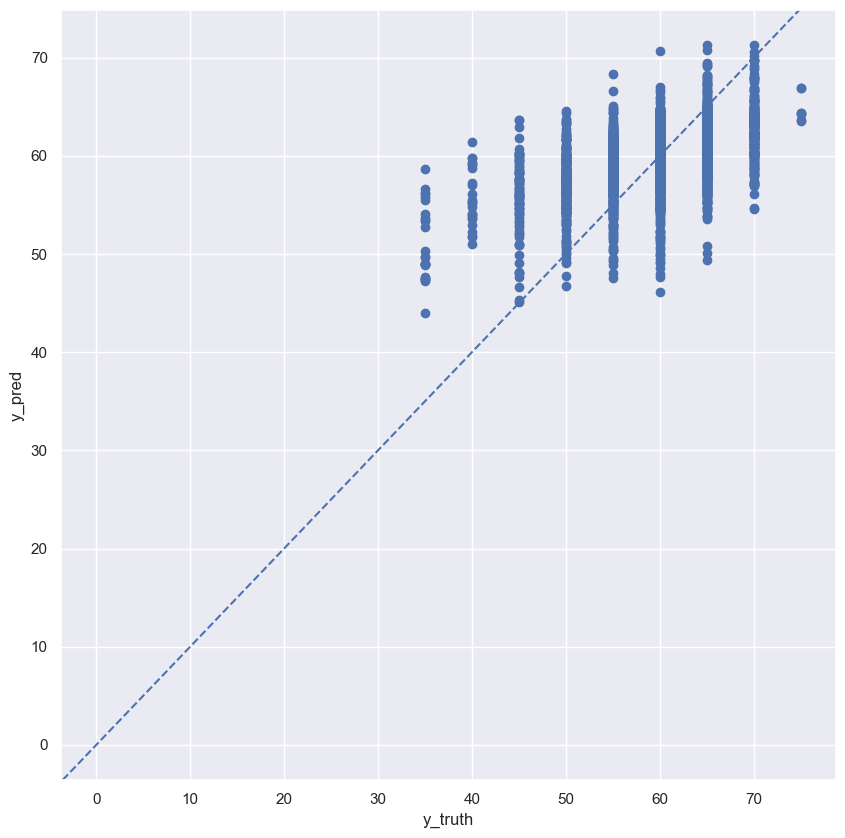

In [147]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_reg'] = y_test - y_pred
plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [148]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 2334 entries, 11292 to 5651
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          2334 non-null   str    
 1   noise_day        2334 non-null   int64  
 2   noise_evening    2334 non-null   int64  
 3   noise_night      2334 non-null   int64  
 4   road_length      2334 non-null   float64
 5   road_category    2334 non-null   int64  
 6   dist_to_main     2334 non-null   float64
 7   signals          2334 non-null   float64
 8   transport        2334 non-null   float64
 9   pois             2334 non-null   float64
 10  width            2334 non-null   float64
 11  height           2334 non-null   float64
 12  betw_centrality  2334 non-null   float64
 13  clos_centrality  2334 non-null   float64
 14  green_100        2334 non-null   float64
 15  diff_reg         2334 non-null   float64
dtypes: float64(11), int64(4), str(1)
memory usage: 310.0 KB


In [149]:
data_test['noisePred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_reg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main', 'signals']
).interactive()

alt.Chart(...)

## XGBoost

### Train with new model

In [150]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))
score_xgb = model.score(X_test, y_test)
data_test['score_xgb'] = score_xgb

0.7570788264274597
0.49089181423187256


### Inspect results

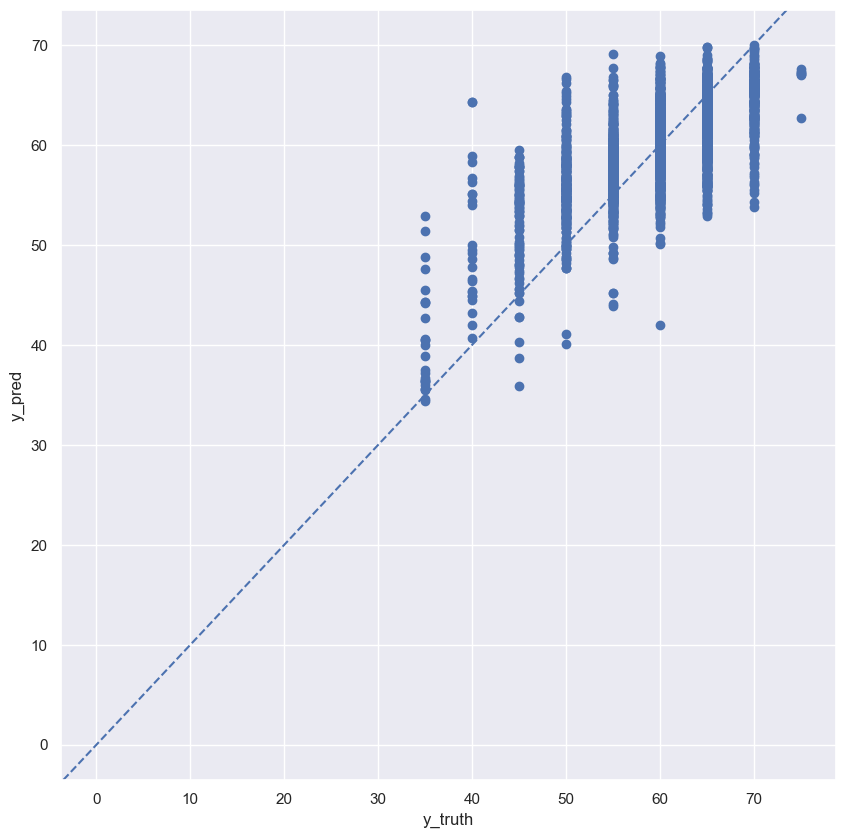

In [151]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_xg'] = y_test - y_pred

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [152]:
data_test['noisePred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main','signals']
).interactive()

alt.Chart(...)

### Compare results

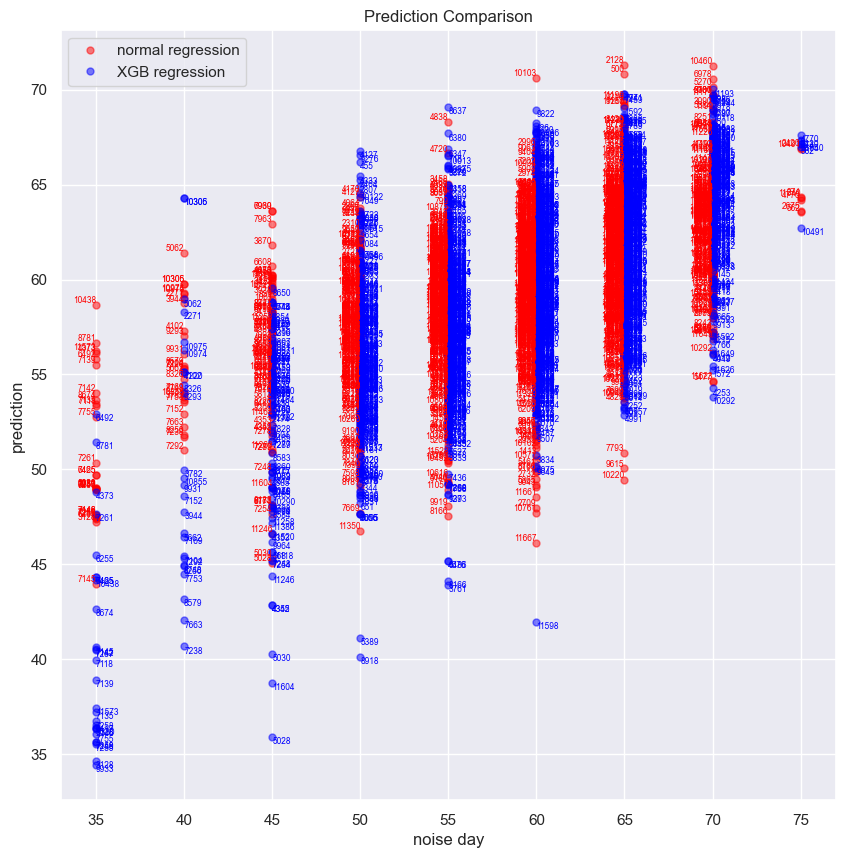

In [153]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('noise day')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()

In [154]:
data_test.shape

(2334, 20)

## Inspect outliers

In [155]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

In [ ]:
# Plot Road Categories
ax = merged_gdf.plot(column='diff_xg', cmap='coolwarm', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()
merged_gdf.explore()

In [ ]:
data_test.columns.to_list()

['road_id',
 'noise_day',
 'noise_evening',
 'noise_night',
 'road_length',
 'road_category',
 'dist_to_main',
 'signals',
 'transport',
 'pois',
 'width',
 'height',
 'betw_centrality',
 'clos_centrality',
 'green_100',
 'diff_reg',
 'noisePred_reg',
 'score_xgb',
 'diff_xg',
 'noisePred_xg']

In [ ]:
df_sorted = data_test.sort_values(by="diff_xg", ascending=False)

df_filtered = df_sorted[(df_sorted['diff_xg'] > -15) & (df_sorted['diff_xg'] < 15)]
df_filtered[['diff_xg']].head(40)
df_filtered.drop(columns=['diff_xg', 'diff_reg','noisePred_xg','noisePred_reg','score_xgb'], inplace=True)
df_filtered.head()

,road_id,noise_day,noise_evening,noise_night,road_length,road_category,dist_to_main,signals,transport,pois,width,height,betw_centrality,clos_centrality,green_100
2145,30617577_30237678_0,70,70,65,67.757,6,314.826,2.952,2.952,7.380,10.980,10.071,0.002,0.000,7.029
5391,568847327_392359251_0,70,65,60,229.306,5,6.063,0.436,1.308,0.436,24.911,5.125,0.006,0.000,0.000
8480,2501701155_2501773162_0,70,70,65,131.813,6,66.073,1.518,2.277,20.492,8.066,8.864,0.000,0.000,0.000
2046,30558390_30558391_0,70,65,60,98.293,6,218.209,5.085,4.068,9.153,9.828,8.647,0.001,0.000,0.000
11649,364997573_364997570_0,70,65,60,42.799,5,265.783,2.335,9.342,2.335,0.000,0.000,0.000,0.000,1.245


In [ ]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_ml_filtered.csv")
df_filtered.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_ml_filtered.csv
